In [11]:
# ==============================================================================
# PIPELINE DI PRE-ELABORAZIONE, ANOMALY DETECTION CAUSALE & PARTIZIONAMENTO
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import warnings

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------------------------
# 1. INGESTIONE DATI & MAPPATURA TICKER
# ------------------------------------------------------------------------------
file_path = 'Dataset3_PortfolioReplicaStrategyErrataCorrige.xlsx'
file_path2 = 'Dataset3_PortfolioReplicaStrategy.xlsx'

# Read full names (row 4)
full_names_df = pd.read_excel(file_path2, header=None, skiprows=3, nrows=1)
full_names = full_names_df.iloc[0].tolist()[1:]

# Read Bloomberg tickers (row 6)
tickers_df = pd.read_excel(file_path2, header=None, skiprows=5, nrows=1)
tickers = tickers_df.iloc[0].tolist()[1:]
variable_info = dict(zip(tickers, full_names))

# Read actual data
data_raw = pd.read_excel(file_path, header=None, skiprows=1)
data_raw.columns = ['Date'] + tickers
data_raw['Date'] = pd.to_datetime(data_raw['Date'], format='%d/%m/%Y')
data = data_raw.set_index('Date').sort_index()

print("Dataset caricato correttamente:")
print(f"Dimensioni: {data.shape[0]} osservazioni, {data.shape[1]} variabili.")
print(f"Periodo: dal {data.index.min().date()} al {data.index.max().date()}\n")

Dataset caricato correttamente:
Dimensioni: 705 osservazioni, 15 variabili.
Periodo: dal 2007-10-23 al 2021-04-20



# LLL1 COMDTY

In [12]:
# ------------------------------------------------------------------------------
# 2. IMPUTAZIONE LINEARE OLS PER LLL1 COMDTY (PASSAGGIO SINGOLO)
# ------------------------------------------------------------------------------
train_ols = data.iloc[:196].dropna()
X_train_ols = train_ols.drop(columns='LLL1 Comdty')
y_train_ols = train_ols['LLL1 Comdty']

model_LR = LinearRegression().fit(X_train_ols, y_train_ols)

X_predict = data.iloc[196:].drop(columns='LLL1 Comdty')
predicted_values = model_LR.predict(X_predict)

# Assegnazione corretta senza Chained Assignment
data.iloc[196:, data.columns.get_loc('LLL1 Comdty')] = predicted_values

print("Imputazione OLS per LLL1 Comdty completata col successo.")

Imputazione OLS per LLL1 Comdty completata col successo.


# Rendimenti e benchmark

In [13]:
# ------------------------------------------------------------------------------
# 3. CALCOLO DEI RENDIMENTI E COSTRUZIONE DEL BENCHMARK TARGET
# ------------------------------------------------------------------------------
# Rendimenti discreti semplici: R_t = (P_t / P_{t-1}) - 1
returns_df = data.pct_change().dropna()

# Costruzione del target composito (o azionario puro, es. MSCI World / USA)
index_components = {
    'HFRXGL Index': 0.50,   # Hedge Fund Index - 50%
    'MXWO Index': 0.25,     # MSCI World - 25%
    'LEGATRUU Index': 0.25  # Global Aggregate Bond - 25%
}

target_returns = pd.Series(0.0, index=returns_df.index, name='Target_Index')
for component, weight in index_components.items():
    target_returns += returns_df[component] * weight

# Calcolo della serie di ricchezza cumulabile P_t
cumulative_returns = (1 + target_returns).cumprod()

# Anomaly detection

In [14]:
# ------------------------------------------------------------------------------
# 4. ANOMALY DETECTION CAUSALE (ZERO LOOK-AHEAD BIAS)
# ------------------------------------------------------------------------------
def detect_causal_crashes(cum_returns_series, window=20, dd_threshold=-0.035):
    """
    Identifica i periodi di stress di mercato basandosi esclusivamente sul
    Drawdown Peak-to-Valley mobile del passato e del presente (100% causale).
    
    Parameters:
    - cum_returns_series: pd.Series con i prezzi / rendimenti cumulati storici.
    - window: int, finestra mobile in giorni per il calcolo del massimo storico (Peak).
    - dd_threshold: float, soglia percentuale di drawdown al di sotto della quale
                    scatta l'allarme stress (es. -0.035 per un calo del 3.5%).
                    
    Returns:
    - crash_labels: pd.Series binaria (1 = Stress/Crash, 0 = Mercato Normale).
    """
    # Calcolo del massimo storico locale nei precedenti 'window' periodi
    rolling_peak = cum_returns_series.rolling(window=window, min_periods=1).max()
    
    # Drawdown percentuale istantaneo rispetto al picco locale
    drawdown = (cum_returns_series - rolling_peak) / rolling_peak
    
    # Etichetta binaria: 1 se il drawdown supera la soglia di stress
    crash_labels = (drawdown < dd_threshold).astype(int)
    crash_labels.name = "Crash"
    
    return crash_labels

# Generazione delle etichette causali di stress
y_causal = detect_causal_crashes(cumulative_returns, window=20, dd_threshold=-0.035)

print("\n--- RIEPILOGO ANOMALY DETECTION CAUSALE ---")
print(f"Totale periodi di stress individuati: {y_causal.sum()} ({y_causal.mean()*100:.2f}% del campione).")

# Salva le etichette su CSV (opzionale, per backup)
y_causal.to_csv("causal_crash_labels.csv", header=True)


--- RIEPILOGO ANOMALY DETECTION CAUSALE ---
Totale periodi di stress individuati: 126 (17.90% del campione).


# Dataset (Training - Validation - Test)

In [15]:
# ------------------------------------------------------------------------------
# 5. DIVISIONE CRONOLOGICA DEL DATASET (60% TRAIN / 20% VAL / 20% TEST)
# ------------------------------------------------------------------------------
# Matrice delle variabili di replica (futures/indici) e target di stress
X_features = returns_df.copy()
y_target = y_causal.loc[X_features.index]

T_total = len(X_features)
idx_train = int(T_total * 0.60)
idx_val = int(T_total * 0.80)

# Partizionamento a blocchi senza rimescolamento casuale (NO SHUFFLE)
X_train = X_features.iloc[:idx_train]
X_val   = X_features.iloc[idx_train:idx_val]
X_test  = X_features.iloc[idx_val:]

y_train = y_target.iloc[:idx_train]
y_val   = y_target.iloc[idx_train:idx_val]
y_test  = y_target.iloc[idx_val:]

print("\n--- PARTIZIONAMENTO CRONOLOGICO (BLOCK SPLIT) ---")
print(f"Training Set   (60%): dal {X_train.index.min().date()} al {X_train.index.max().date()} | {len(X_train)} obs | Stress: {y_train.sum()} gg")
print(f"Validation Set (20%): dal {X_val.index.min().date()} al {X_val.index.max().date()}   | {len(X_val)} obs  | Stress: {y_val.sum()} gg")
print(f"Test Set       (20%): dal {X_test.index.min().date()} al {X_test.index.max().date()}   | {len(X_test)} obs  | Stress: {y_test.sum()} gg")


--- PARTIZIONAMENTO CRONOLOGICO (BLOCK SPLIT) ---
Training Set   (60%): dal 2007-10-30 al 2015-11-24 | 422 obs | Stress: 84 gg
Validation Set (20%): dal 2015-12-01 al 2018-08-07   | 141 obs  | Stress: 15 gg
Test Set       (20%): dal 2018-08-14 al 2021-04-20   | 141 obs  | Stress: 27 gg


# Dataset normalization

In [16]:
# ------------------------------------------------------------------------------
# 6. NORMALIZZAZIONE A TENUTA STAGNA (ZERO DATA LEAKAGE)
# ------------------------------------------------------------------------------
scaler = StandardScaler()

# 1. Calibrazione di media e varianza ESCLUSIVAMENTE sul Training Set
scaler.fit(X_train.values)

# 2. Trasformazione delle tre partizioni usando i parametri statici del Training
X_train_scaled = pd.DataFrame(scaler.transform(X_train.values), index=X_train.index, columns=X_train.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val.values), index=X_val.index, columns=X_val.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test.values), index=X_test.index, columns=X_test.columns)

print("\nVerifica Normalizzazione (Training Set):")
print(f"Media massima delle feature (deve essere ~0): {X_train_scaled.mean().abs().max():.6f}")
print(f"Dev. Std massima delle feature (deve essere ~1): {X_train_scaled.std().max():.6f}")


Verifica Normalizzazione (Training Set):
Media massima delle feature (deve essere ~0): 0.000000
Dev. Std massima delle feature (deve essere ~1): 1.001187


# Dataset visualization

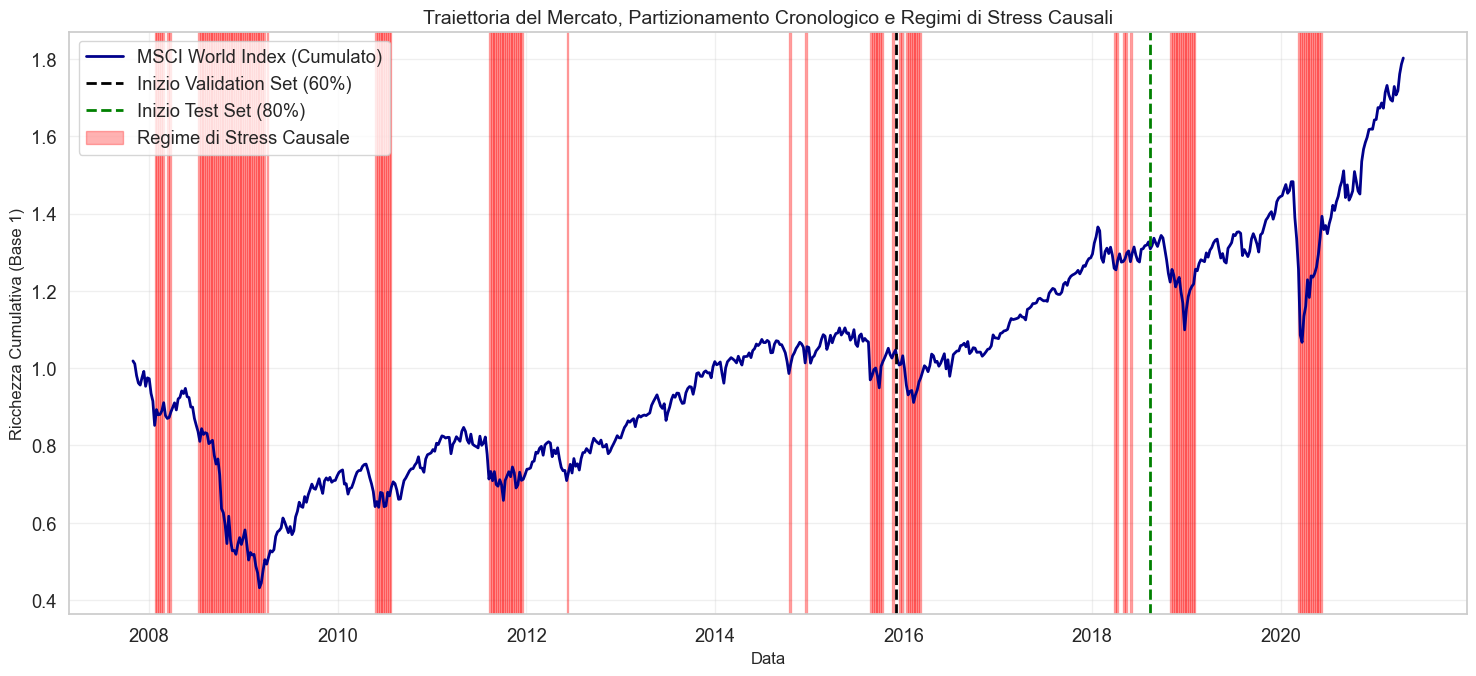

In [17]:
# ------------------------------------------------------------------------------
# 7. VISUALIZZAZIONE DEL DATASET CON REGOLE E REGIMI DI STRESS
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 7))

# Traiettoria dell'indice di riferimento (es. MSCI World o USA)
plot_series = (1 + returns_df['MXWO Index']).cumprod()
ax.plot(plot_series.index, plot_series, color='darkblue', linewidth=2.0, label='MSCI World Index (Cumulato)')

# Segna le partizioni cronologiche
ax.axvline(X_val.index[0], color='black', linestyle='--', linewidth=2, label='Inizio Validation Set (60%)')
ax.axvline(X_test.index[0], color='green', linestyle='--', linewidth=2, label='Inizio Test Set (80%)')

# Evidenzia i regimi di stress causali individuati
crash_dates = y_target.index[y_target == 1]
for i, date in enumerate(crash_dates):
    ax.axvspan(date, date + pd.Timedelta(days=7), color='red', alpha=0.3, label='Regime di Stress Causale' if i == 0 else "")

ax.set_title('Traiettoria del Mercato, Partizionamento Cronologico e Regimi di Stress Causali', fontsize=14)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Ricchezza Cumulativa (Base 1)', fontsize=12)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Regression baseline

--- PARTIZIONAMENTO PER BASELINE OLS ---
Train Set (60%): 422 settimane | dal 2007-10-30 al 2015-11-24
Val Set   (20%): 141 settimane   | dal 2015-12-01 al 2018-08-07
Test Set  (20%): 141 settimane  | dal 2018-08-14 al 2021-04-20

Pesi OLS Stimati nel Training Set (w_hat):
RX1 Comdty     0.0688
TY1 Comdty     0.1758
GC1 Comdty     0.0247
CO1 Comdty     0.0233
ES1 Comdty     0.1342
VG1 Comdty     0.0670
NQ1 Comdty     0.0088
LLL1 Comdty    0.0375
TP1 Comdty     0.0511
DU1 Comdty    -0.4582
TU2 Comdty     0.1527
Name: OLS_Weight, dtype: float64

Esposizione Lorda Statica (Gross Exposure): 1.2022



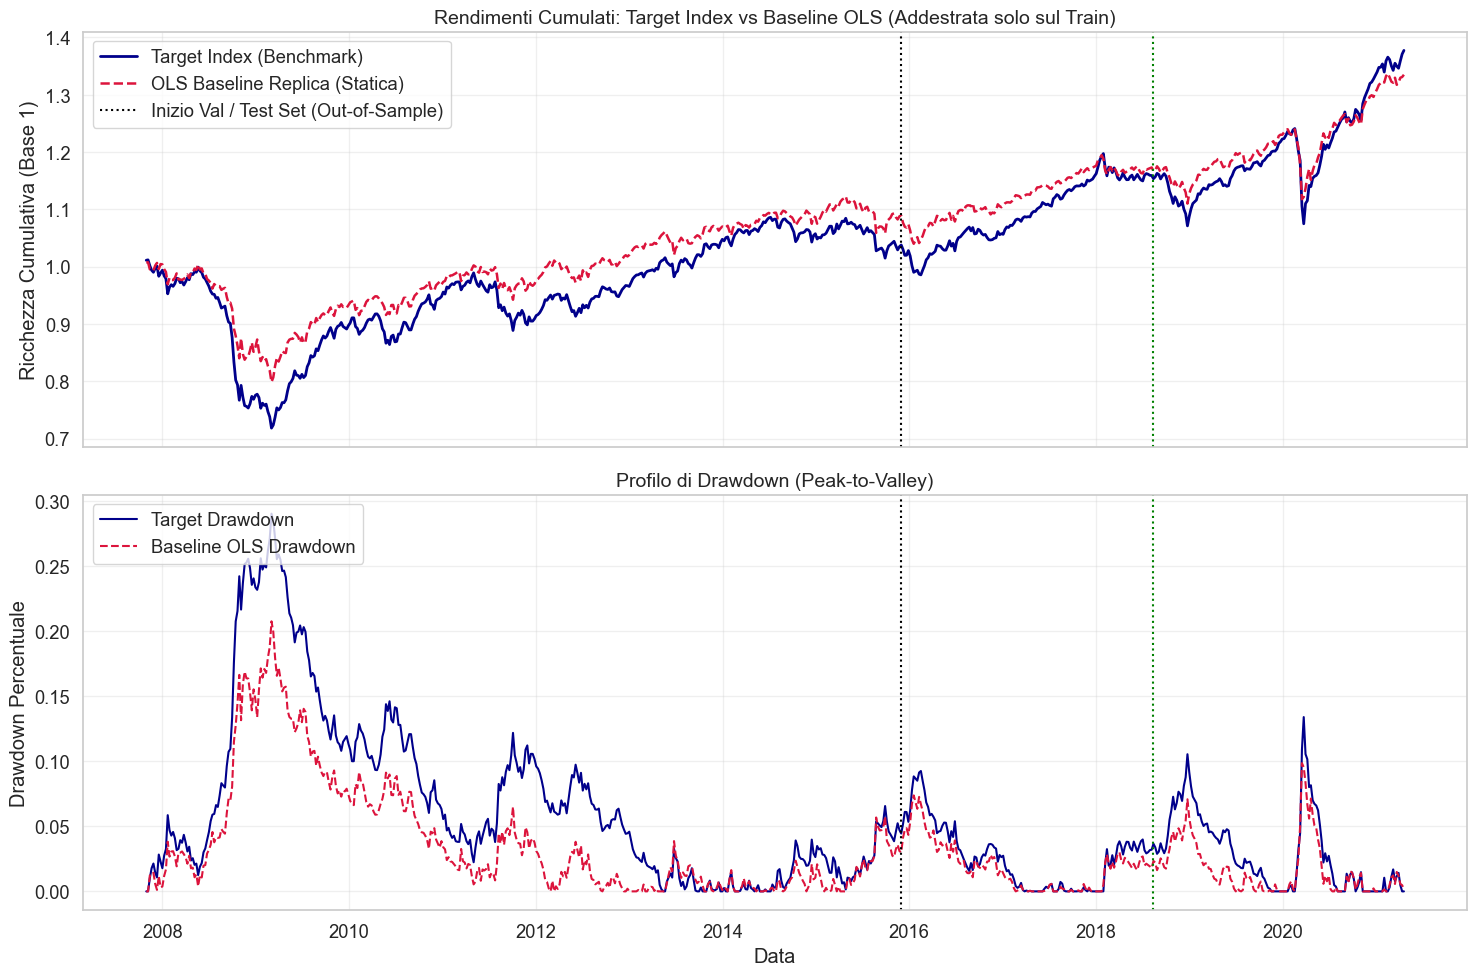

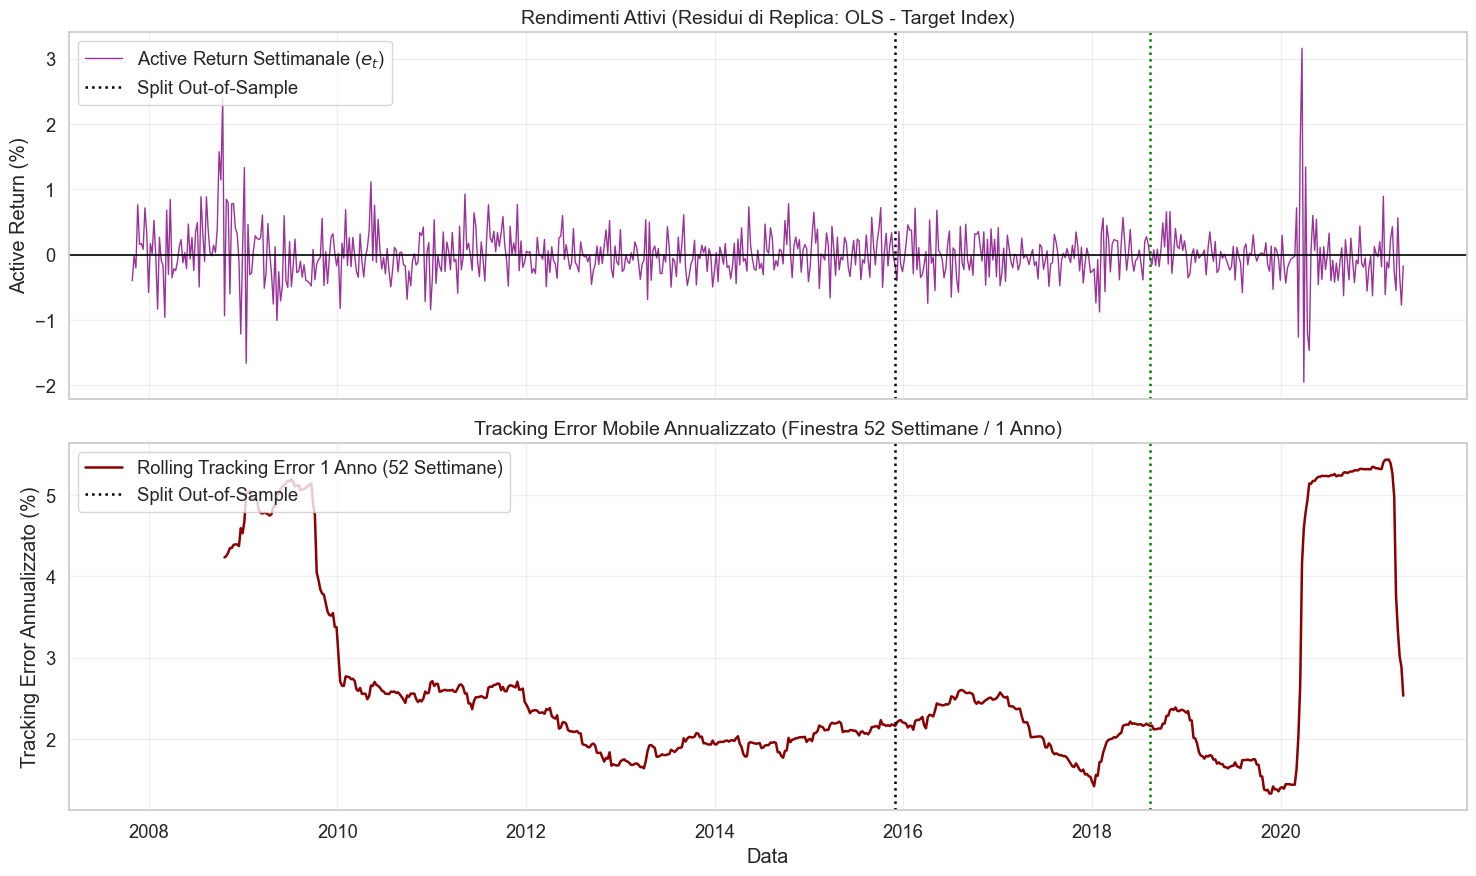

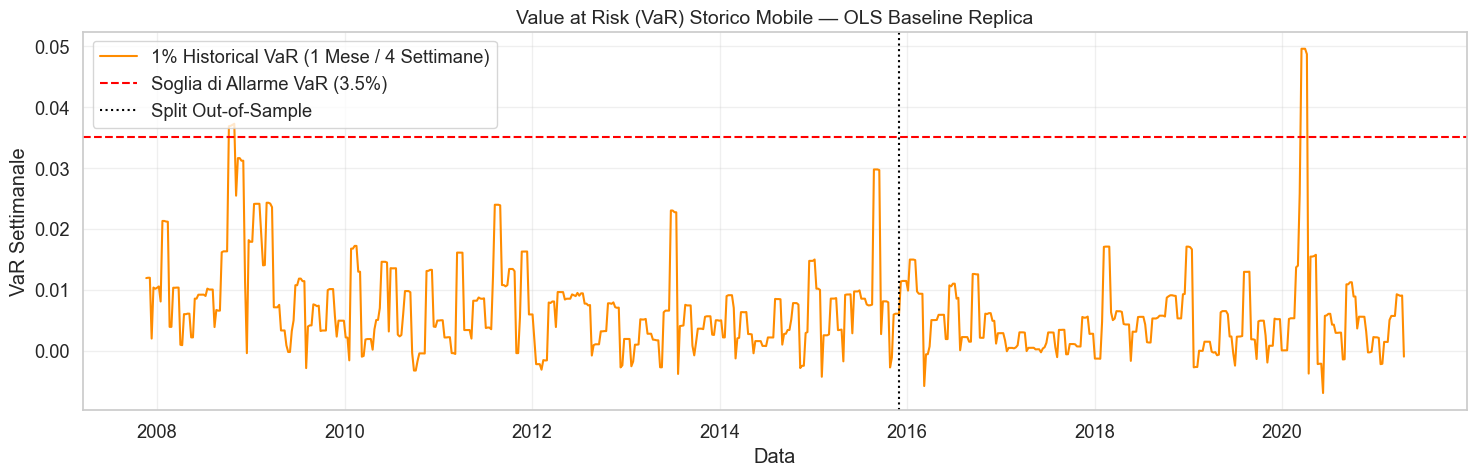

             TABELLA DELLE METRICHE ISTITUZIONALI: BASELINE OLS               


,Metrica,Train (In-Sample),Validation (OOS),Test (OOS Puro)
0,Rendimento Annualizzato,1.23%,2.88%,5.06%
1,Volatilità Annualizzata,6.02%,3.52%,5.84%
2,Sharpe Ratio (Rf=0),0.20,0.82,0.87
3,Max Drawdown,20.74%,4.52%,9.85%
4,Tracking Error (vs Target),2.81%,2.17%,3.59%
5,Information Ratio,0.20,-0.65,-0.47
6,Correlazione con Target,0.9062,0.8505,0.8647
7,Esposizione Lorda (Gross Exp.),1.20,1.20,1.20


In [19]:
# ==============================================================================
# STRATEGIA DI REPLICA STATICA OLS (BASELINE ZERO LOOK-AHEAD BIAS)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# 1. SELEZIONE DELLE VARIABILI DI REPLICA E PARTIZIONAMENTO CRONOLOGICO
# ------------------------------------------------------------------------------
# Assumiamo che 'target_returns' (Y) e 'returns_df' siano già calcolati dalla pre-elaborazione
futures_contracts = [
    'RX1 Comdty', 'TY1 Comdty', 'GC1 Comdty', 'CO1 Comdty',
    'ES1 Comdty', 'VG1 Comdty', 'NQ1 Comdty', 'LLL1 Comdty',
    'TP1 Comdty', 'DU1 Comdty', 'TU2 Comdty'
]

# Allineamento rigoroso tra indice target (Y) e universo futures (C)
common_dates = target_returns.index.intersection(returns_df.index)
Y = target_returns.loc[common_dates]
C = returns_df.loc[common_dates, futures_contracts]

T_total = len(Y)
idx_train = int(T_total * 0.60)
idx_val = int(T_total * 0.80)

# Partizionamento rigoroso senza mescolamento (No Shuffle)
Y_train, C_train = Y.iloc[:idx_train], C.iloc[:idx_train]
Y_val,   C_val   = Y.iloc[idx_train:idx_val], C.iloc[idx_train:idx_val]
Y_test,  C_test  = Y.iloc[idx_val:], C.iloc[idx_val:]

print("--- PARTIZIONAMENTO PER BASELINE OLS ---")
print(f"Train Set (60%): {len(Y_train)} settimane | dal {Y_train.index.min().date()} al {Y_train.index.max().date()}")
print(f"Val Set   (20%): {len(Y_val)} settimane   | dal {Y_val.index.min().date()} al {Y_val.index.max().date()}")
print(f"Test Set  (20%): {len(Y_test)} settimane  | dal {Y_test.index.min().date()} al {Y_test.index.max().date()}\n")

# ------------------------------------------------------------------------------
# 2. STIMA DEI PESI OLS ESCLUSIVAMENTE IN-SAMPLE (TRAINING SET)
# ------------------------------------------------------------------------------
# In un portafoglio di replica pura si omette spesso l'intercetta (fit_intercept=False)
# per forzare la replica dei rendimenti via pura combinazione lineare degli asset
model_ols = LinearRegression(fit_intercept=False).fit(C_train.values, Y_train.values)

# Pesi statici di replica stimati nel passato
weights_baseline = pd.Series(model_ols.coef_, index=futures_contracts, name="OLS_Weight")
print("Pesi OLS Stimati nel Training Set (w_hat):")
print(weights_baseline.round(4))
print(f"\nEsposizione Lorda Statica (Gross Exposure): {weights_baseline.abs().sum():.4f}\n")

# ------------------------------------------------------------------------------
# 3. PROIEZIONE DEI RENDIMENTI DI REPLICA OUT-OF-SAMPLE
# ------------------------------------------------------------------------------
# Calcolo del rendimento della replica: R_baseline(t) = C(t) * w_hat
baseline_train = pd.Series(model_ols.predict(C_train.values), index=C_train.index)
baseline_val   = pd.Series(model_ols.predict(C_val.values),   index=C_val.index)
baseline_test  = pd.Series(model_ols.predict(C_test.values),  index=C_test.index)

# Ricomposizione dell'intera serie per la visualizzazione grafica
baseline_returns_full = pd.concat([baseline_train, baseline_val, baseline_test])

# ------------------------------------------------------------------------------
# 4. VISUALIZZAZIONE GRAFICA: TRAIETTORIA CUMULATA E DRAWDOWNS
# ------------------------------------------------------------------------------
cum_target   = (1 + Y).cumprod()
cum_baseline = (1 + baseline_returns_full).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Rendimenti Cumulati
axes[0].plot(cum_target.index, cum_target, label='Target Index (Benchmark)', color='darkblue', linewidth=2)
axes[0].plot(cum_baseline.index, cum_baseline, label='OLS Baseline Replica (Statica)', color='crimson', linewidth=1.8, linestyle='--')
axes[0].axvline(Y_val.index[0], color='black', linestyle=':', label='Inizio Val / Test Set (Out-of-Sample)')
axes[0].axvline(Y_test.index[0], color='green', linestyle=':')
axes[0].set_title('Rendimenti Cumulati: Target Index vs Baseline OLS (Addestrata solo sul Train)', fontsize=14)
axes[0].set_ylabel('Ricchezza Cumulativa (Base 1)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Drawdowns
dd_target   = 1 - cum_target / cum_target.cummax()
dd_baseline = 1 - cum_baseline / cum_baseline.cummax()

axes[1].plot(dd_target.index, dd_target, label='Target Drawdown', color='darkblue', linewidth=1.5)
axes[1].plot(dd_baseline.index, dd_baseline, label='Baseline OLS Drawdown', color='crimson', linewidth=1.5, linestyle='--')
axes[1].axvline(Y_val.index[0], color='black', linestyle=':')
axes[1].axvline(Y_test.index[0], color='green', linestyle=':')
axes[1].set_title('Profilo di Drawdown (Peak-to-Valley)', fontsize=14)
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Drawdown Percentuale')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# ------------------------------------------------------------------------------
# 4.bis ANALISI DEI RESIDUI (ACTIVE RETURNS) E ROLLING TRACKING ERROR
# ------------------------------------------------------------------------------
# Calcolo dei rendimenti attivi settimanali (residui di replica): e_t = R_replica - R_target
active_returns = baseline_returns_full - Y

# Calcolo del Tracking Error mobile annualizzato su finestra di 1 anno (52 settimane)
rolling_te_window = 52
rolling_te = active_returns.rolling(window=rolling_te_window).std() * np.sqrt(52)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# 1. Grafico dei Rendimenti Attivi (Residui e_t)
axes[0].plot(active_returns.index, active_returns * 100, color='purple', linewidth=1.0, alpha=0.8, label='Active Return Settimanale ($e_t$)')
axes[0].axhline(0, color='black', linestyle='-', linewidth=1.2)
axes[0].axvline(Y_val.index[0], color='black', linestyle=':', linewidth=1.8, label='Split Out-of-Sample')
axes[0].axvline(Y_test.index[0], color='green', linestyle=':', linewidth=1.8)
axes[0].set_title('Rendimenti Attivi (Residui di Replica: OLS - Target Index)', fontsize=14)
axes[0].set_ylabel('Active Return (%)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Grafico del Rolling Tracking Error Annualizzato (Finestra 52 settimane)
axes[1].plot(rolling_te.index, rolling_te * 100, color='darkred', linewidth=1.8, label='Rolling Tracking Error 1 Anno (52 Settimane)')
axes[1].axvline(Y_val.index[0], color='black', linestyle=':', linewidth=1.8, label='Split Out-of-Sample')
axes[1].axvline(Y_test.index[0], color='green', linestyle=':', linewidth=1.8)
axes[1].set_title('Tracking Error Mobile Annualizzato (Finestra 52 Settimane / 1 Anno)', fontsize=14)
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Tracking Error Annualizzato (%)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# ------------------------------------------------------------------------------
# 5. CALCOLO DEL HISTORICAL VaR AL 1% (su Finestra 1 Mese / 4 Settimane)
# ------------------------------------------------------------------------------
var_window = 4  # 4 settimane = 1 mese operativo
conf_level = 0.01

var_series = -baseline_returns_full.rolling(window=var_window).quantile(conf_level)
max_var_threshold = 0.035  # Es. 3.5% settimanale

plt.figure(figsize=(15, 5))
plt.plot(var_series.index, var_series, color='darkorange', linewidth=1.5, label='1% Historical VaR (1 Mese / 4 Settimane)')
plt.axhline(y=max_var_threshold, color='red', linestyle='--', label=f'Soglia di Allarme VaR ({max_var_threshold*100:.1f}%)')
plt.axvline(Y_val.index[0], color='black', linestyle=':', label='Split Out-of-Sample')
plt.title('Value at Risk (VaR) Storico Mobile — OLS Baseline Replica', fontsize=14)
plt.xlabel('Data')
plt.ylabel('VaR Settimanale')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. MOTORE DI CALCOLO DELLE METRICHE ISTITUZIONALI (FREQ SETTIMANALE = 52)
# ------------------------------------------------------------------------------
def compute_metrics(r_target, r_replica, freq=52):
    """Calcola le metriche istituzionali annualizzate su un sub-campione."""
    ann_ret = (1 + r_replica.mean())**freq - 1
    ann_vol = r_replica.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else 0
    
    cum_r = (1 + r_replica).cumprod()
    max_dd = (1 - cum_r / cum_r.cummax()).max()
    
    # Metriche di replica rispetto al benchmark target
    diff = r_replica - r_target
    te = diff.std() * np.sqrt(freq)  # Tracking Error annualizzato
    ir = (diff.mean() * freq) / te if te != 0 else 0  # Information Ratio
    corr = np.corrcoef(r_replica, r_target)[0, 1]
    
    return [ann_ret, ann_vol, sharpe, max_dd, te, ir, corr]

# Calcolo separato sulle tre partizioni
metrics_train = compute_metrics(Y_train, baseline_train)
metrics_val   = compute_metrics(Y_val,   baseline_val)
metrics_test  = compute_metrics(Y_test,  baseline_test)

# Aggiunta esposizione lorda e costi di transazione
# Nota: La OLS statica non fa rebalancing (pesi costanti), quindi il costo di turnover è 0 
# ad eccezione del drift dei prezzi. Lo poniamo pari al Gross Exposure fisso.
gross_exp = weights_baseline.abs().sum()

metrics_df = pd.DataFrame({
    'Metrica': [
        'Rendimento Annualizzato', 'Volatilità Annualizzata', 'Sharpe Ratio (Rf=0)',
        'Max Drawdown', 'Tracking Error (vs Target)', 'Information Ratio',
        'Correlazione con Target', 'Esposizione Lorda (Gross Exp.)'
    ],
    'Train (In-Sample)': [
        f"{metrics_train[0]*100:.2f}%", f"{metrics_train[1]*100:.2f}%", f"{metrics_train[2]:.2f}",
        f"{metrics_train[3]*100:.2f}%", f"{metrics_train[4]*100:.2f}%", f"{metrics_train[5]:.2f}",
        f"{metrics_train[6]:.4f}", f"{gross_exp:.2f}"
    ],
    'Validation (OOS)': [
        f"{metrics_val[0]*100:.2f}%", f"{metrics_val[1]*100:.2f}%", f"{metrics_val[2]:.2f}",
        f"{metrics_val[3]*100:.2f}%", f"{metrics_val[4]*100:.2f}%", f"{metrics_val[5]:.2f}",
        f"{metrics_val[6]:.4f}", f"{gross_exp:.2f}"
    ],
    'Test (OOS Puro)': [
        f"{metrics_test[0]*100:.2f}%", f"{metrics_test[1]*100:.2f}%", f"{metrics_test[2]:.2f}",
        f"{metrics_test[3]*100:.2f}%", f"{metrics_test[4]*100:.2f}%", f"{metrics_test[5]:.2f}",
        f"{metrics_test[6]:.4f}", f"{gross_exp:.2f}"
    ]
})

print("==============================================================================")
print("             TABELLA DELLE METRICHE ISTITUZIONALI: BASELINE OLS               ")
print("==============================================================================")
display(metrics_df)

# KF+HMM+Optuna

--- PARTIZIONAMENTO KALMAN & OPTUNA ---
Train Set (60%): 422 sett. | Val Set (20%): 141 sett. | Test Set (20%): 141 sett.

Avvio ricerca iperparametri Optuna (Valutazione isolata su Validation Set)...
Ottimizzazione terminata. Miglior Tracking Error sul Val Set: 2.05%
Parametri Ottimi Q: {0: 0.0023933421274794134, 1: 0.00016002763322221937, 2: 0.10786510468959733}
Parametri Ottimi R: {0: 0.003394457918734284, 1: 0.003549993459192183, 2: 0.012514726839551895}



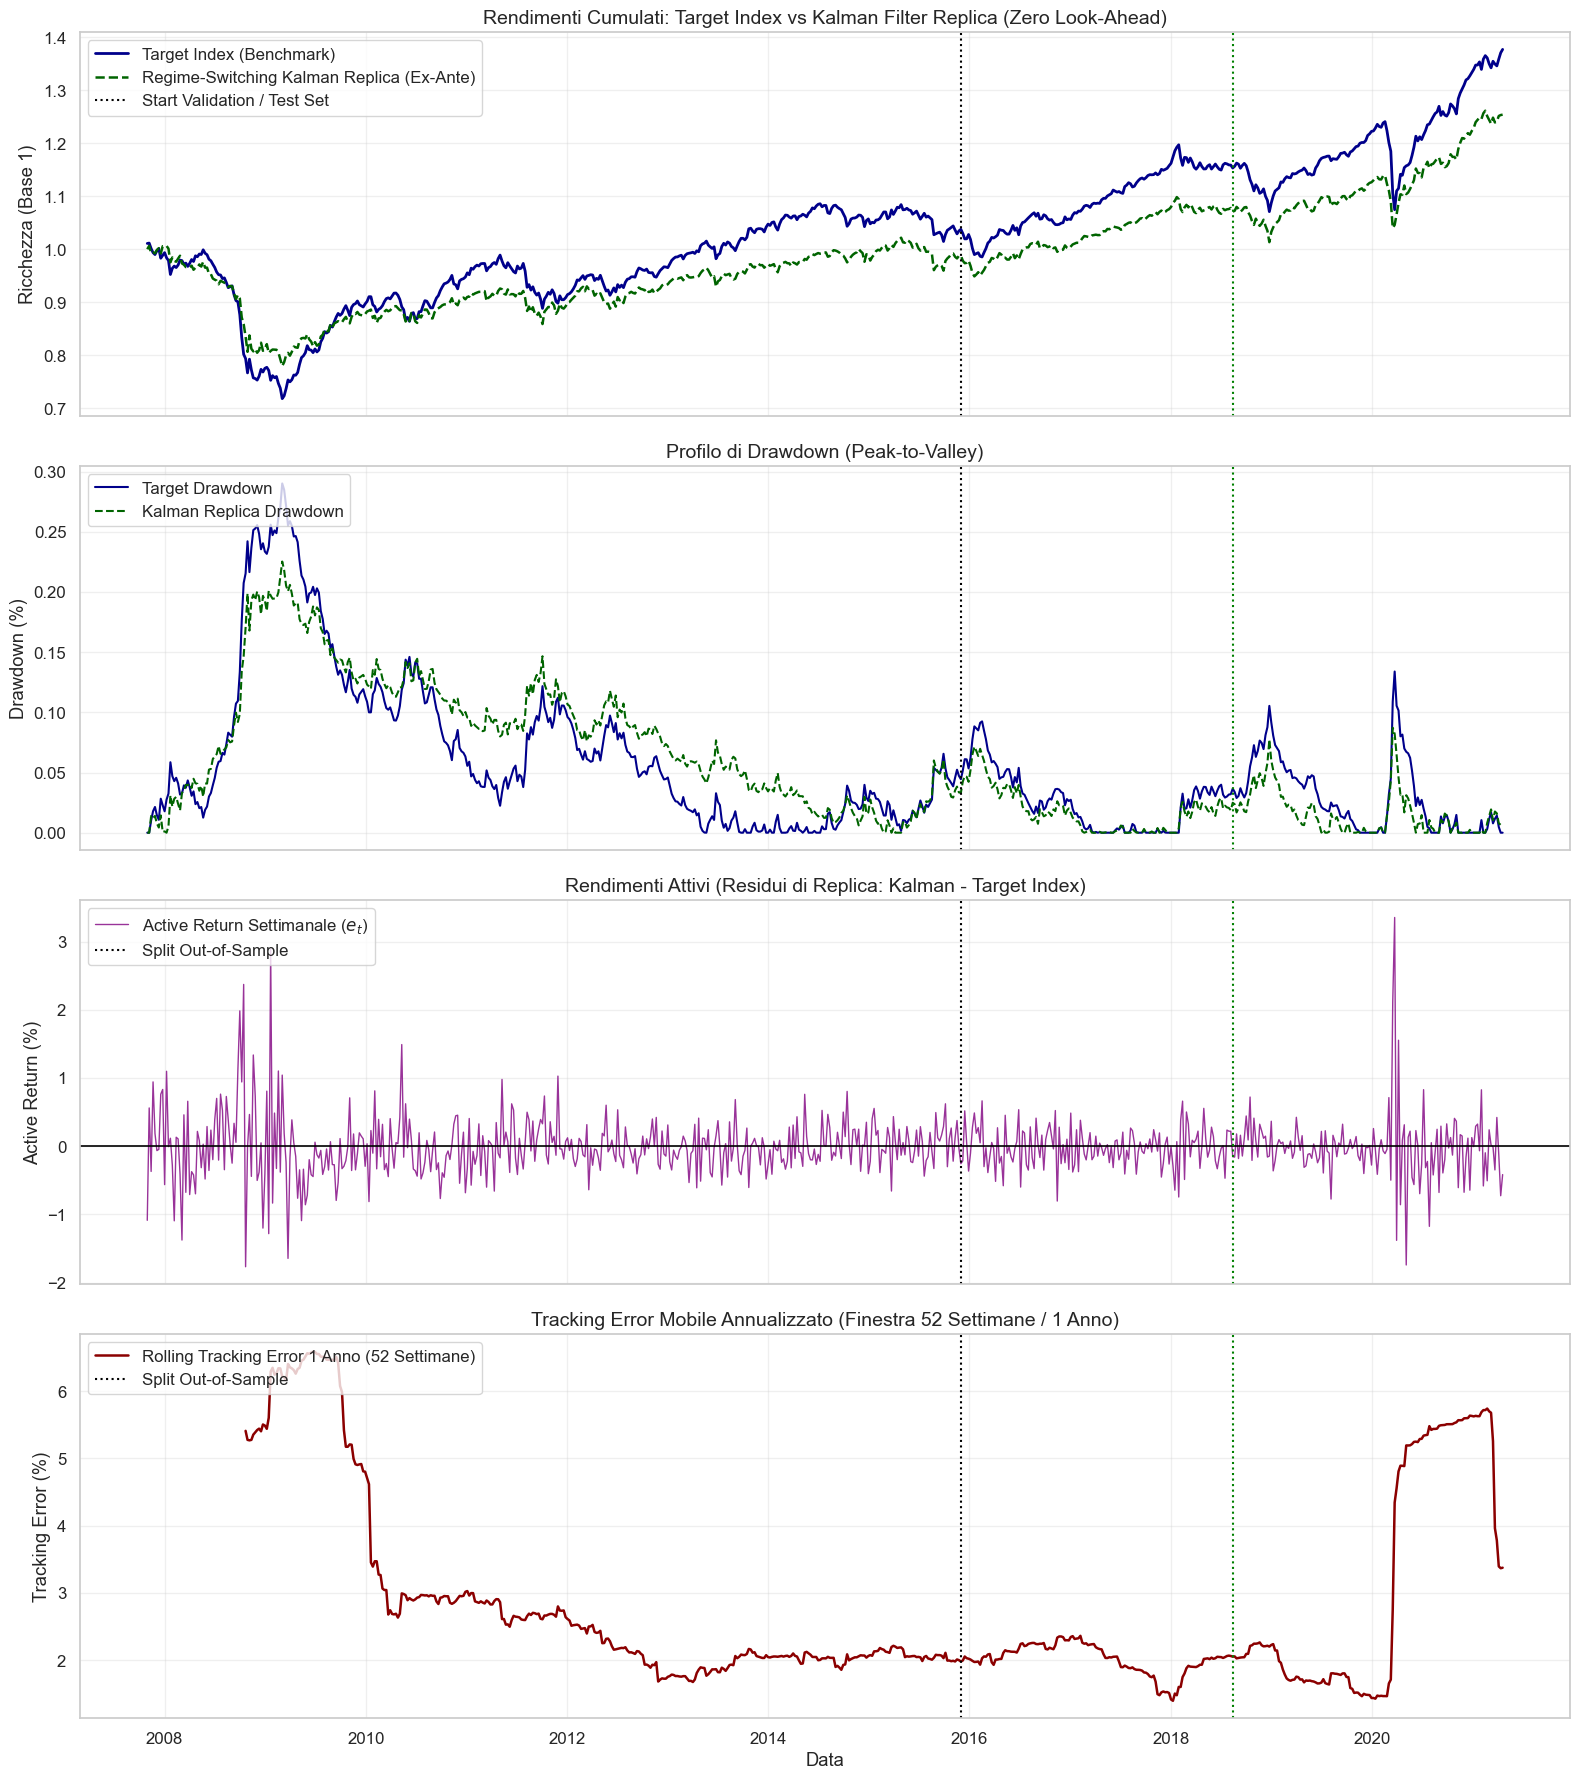

       TABELLA DELLE METRICHE: REGIME-SWITCHING KALMAN REPLICATOR             


,Metrica,Train (In-Sample),Validation (OOS),Test (OOS Puro)
0,Rendimento Annualizzato,0.03%,3.34%,5.93%
1,Volatilità Annualizzata,6.04%,3.45%,6.01%
2,Sharpe Ratio (Rf=0),0.01,0.97,0.99
3,Max Drawdown,22.53%,3.96%,8.72%
4,Tracking Error (vs Target),3.31%,2.06%,3.72%
5,Information Ratio,-0.18,-0.48,-0.23
6,Correlazione con Target,0.8682,0.8678,0.8520
7,Esposizione Lorda Media (Gross Exp.),0.85,0.86,0.93


In [20]:
# ==============================================================================
# STRATEGIA DI REPLICA DINAMICA: HMM + REGIME-SWITCHING KALMAN FILTER + OPTUNA
# (Strict Causal Execution & Zero Look-Ahead Bias)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.linear_model import Ridge
import optuna
import warnings

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ------------------------------------------------------------------------------
# 1. ALLINEAMENTO E PARTIZIONAMENTO CRONOLOGICO (60% / 20% / 20%)
# ------------------------------------------------------------------------------
# Assumiamo Y (target_returns) e C (futures_returns per gli 11 contratti) già puliti
common_dates = Y.index.intersection(C.index)
Y = Y.loc[common_dates]
C = C.loc[common_dates]

T_total = len(Y)
idx_train = int(T_total * 0.60)
idx_val   = int(T_total * 0.80)

Y_train, C_train = Y.iloc[:idx_train], C.iloc[:idx_train]
Y_val,   C_val   = Y.iloc[idx_train:idx_val], C.iloc[idx_train:idx_val]
Y_test,  C_test  = Y.iloc[idx_val:], C.iloc[idx_val:]

print(f"--- PARTIZIONAMENTO KALMAN & OPTUNA ---")
print(f"Train Set (60%): {len(Y_train)} sett. | Val Set (20%): {len(Y_val)} sett. | Test Set (20%): {len(Y_test)} sett.\n")

# ------------------------------------------------------------------------------
# 2. CAUSAL HMM REGIME DETECTION (Addestrato solo sul Train Set)
# ------------------------------------------------------------------------------
# Utilizziamo i rendimenti storici e la volatilità rolling breve per identificare i regimi
X_train_hmm = Y_train.values.reshape(-1, 1)

# Fit di un Gaussian HMM a 3 stati ESCLUSIVAMENTE sul Training Set
model_HMM = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
model_HMM.fit(X_train_hmm)

def predict_causal_regimes(model, series):
    """
    Calcola i regimi passo-passo (Forward Filtering - probabilità alpha) 
    per evitare il Look-Ahead Bias del Viterbi smoothing sull'intero campione.
    """
    X = series.values.reshape(-1, 1)
    T = len(X)
    log_frameprob = model._compute_log_likelihood(X)
    log_startprob = np.log(model.startprob_ + 1e-10)
    log_transmat  = np.log(model.transmat_ + 1e-10)
    
    causal_regimes = np.zeros(T, dtype=int)
    work_buffer = log_startprob + log_frameprob[0]
    causal_regimes[0] = np.argmax(work_buffer)
    
    for t in range(1, T):
        max_log = np.max(work_buffer)
        alpha_prev = np.exp(work_buffer - max_log)
        trans_prob = np.dot(alpha_prev, model.transmat_)
        work_buffer = np.log(trans_prob + 1e-10) + max_log + log_frameprob[t]
        causal_regimes[t] = np.argmax(work_buffer)
        
    return causal_regimes

# Generazione rigorosamente causale dell'intera serie dei regimi
regime_series = pd.Series(predict_causal_regimes(model_HMM, Y), index=Y.index)

# Ordinamento regimi per volatilità crescente (0=Calma, 1=Volatilità, 2=Crisi)
reg_vols = Y.groupby(regime_series).std().sort_values()
reg_map = {old_id: new_id for new_id, old_id in enumerate(reg_vols.index)}
regime_series = regime_series.map(reg_map).astype(int)

# ------------------------------------------------------------------------------
# 3. CLASSE ISTITUZIONALE: REGIME-SWITCHING KALMAN PORTFOLIO REPLICATOR
# ------------------------------------------------------------------------------
class InstitutionalKalmanReplicator:
    def __init__(self, Q_std_regimes, R_std_regimes, transaction_cost=0.0005):
        self.Q_std_regimes = Q_std_regimes
        self.R_std_regimes = R_std_regimes
        self.transaction_cost = transaction_cost
        self.is_fitted = False

    def fit(self, Y_vals, C_vals, regimes, ridge_alpha=1.0):
        T, N = C_vals.shape
        self.N = N
        self.x_filtered  = np.zeros((T, N))
        self.x_predicted = np.zeros((T, N))
        self.y_hat_exante = np.zeros(T)
        self.transaction_costs = np.zeros(T)

        # Inizializzazione Ridge sul primo trimestre (12 settimane del Train Set)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=False).fit(C_vals[:12], Y_vals[:12])
        x_prev = ridge.coef_
        P_prev = np.eye(N) * 0.01

        for t in range(T):
            reg = int(regimes[t])
            Q = np.eye(N) * (self.Q_std_regimes.get(reg, 0.01) ** 2)
            R = self.R_std_regimes.get(reg, 0.01) ** 2

            Ct = C_vals[t].reshape(1, -1)
            y_t = Y_vals[t]

            # 1. PREDICIBILITÀ EX-ANTE (A Priori w_{t|t-1})
            x_pred = x_prev
            P_pred = P_prev + Q

            # Rendimento atteso EX-ANTE prima di conoscere l'esito di mercato y_t
            y_hat_t = (Ct @ x_pred).item()

            # 2. AGGIORNAMENTO A POSTERIORI (Kalman Gain)
            S = (Ct @ P_pred @ Ct.T).item() + R
            K = (P_pred @ Ct.T) / S  # Shape: (N, 1)

            x_new = x_pred + K.flatten() * (y_t - y_hat_t)
            
            # Stabilità Numerica: Forma di Joseph per la covarianza dell'errore
            I_KC = np.eye(N) - K @ Ct
            P_new = I_KC @ P_pred @ I_KC.T + (K @ K.T) * R

            # 3. CALCOLO COSTI DI TRANSAZIONE (Turnover sui pesi ex-ante da t-1 a t)
            if t > 0:
                turnover = np.sum(np.abs(x_pred - self.x_predicted[t-1]))
                tc = self.transaction_cost * turnover
                self.transaction_costs[t] = tc
            else:
                tc = 0.0

            # Salvataggio metriche ex-ante (al netto dei costi di trading)
            self.y_hat_exante[t] = y_hat_t - tc
            self.x_filtered[t]   = x_new
            self.x_predicted[t]  = x_pred

            x_prev, P_prev = x_new, P_new

        self.is_fitted = True
        return self

    def get_exante_weights(self):
        return self.x_predicted  # Pesi legalmente commerciabili (Zero Look-Ahead)

    def predict_returns(self):
        return self.y_hat_exante

# ------------------------------------------------------------------------------
# 4. OPTUNA: META-OTTIMIZZAZIONE STRICTLY SU VALIDATION SET (OOS TE)
# ------------------------------------------------------------------------------
print("Avvio ricerca iperparametri Optuna (Valutazione isolata su Validation Set)...")

def objective(trial):
    # Ricerca logaritmica degli std di covarianza per i 3 regimi
    Q_regimes = {
        0: trial.suggest_float("Q_std_0", 1e-4, 0.05, log=True),
        1: trial.suggest_float("Q_std_1", 1e-4, 0.10, log=True),
        2: trial.suggest_float("Q_std_2", 1e-3, 0.20, log=True),
    }
    R_regimes = {
        0: trial.suggest_float("R_std_0", 1e-4, 0.05, log=True),
        1: trial.suggest_float("R_std_1", 1e-4, 0.10, log=True),
        2: trial.suggest_float("R_std_2", 1e-3, 0.20, log=True),
    }

    # Addestramento temporaneo sul blocco Train + Val
    Y_sub = Y.iloc[:idx_val].values
    C_sub = C.iloc[:idx_val].values
    R_sub = regime_series.iloc[:idx_val].values

    model = InstitutionalKalmanReplicator(Q_std_regimes=Q_regimes, R_std_regimes=R_regimes)
    model.fit(Y_sub, C_sub, R_sub)

    # VALUTAZIONE OBIETTIVO: Solo Tracking Error annualizzato sul Validation Set (da idx_train a idx_val)
    val_pred = model.predict_returns()[idx_train:idx_val]
    val_true = Y_sub[idx_train:idx_val]
    
    val_tracking_error = np.std(val_pred - val_true) * np.sqrt(52)
    return val_tracking_error

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=150)  # 150 trials sono ottimali per convergere senza overfitting

best_params = study.best_params
best_Q = {0: best_params["Q_std_0"], 1: best_params["Q_std_1"], 2: best_params["Q_std_2"]}
best_R = {0: best_params["R_std_0"], 1: best_params["R_std_1"], 2: best_params["R_std_2"]}

print(f"Ottimizzazione terminata. Miglior Tracking Error sul Val Set: {study.best_value*100:.2f}%")
print(f"Parametri Ottimi Q: {best_Q}")
print(f"Parametri Ottimi R: {best_R}\n")

# ------------------------------------------------------------------------------
# 5. ESECUZIONE FINALE E CREAZIONE DELLE SERIE STORICHE DI REPLICA
# ------------------------------------------------------------------------------
model_KPF = InstitutionalKalmanReplicator(Q_std_regimes=best_Q, R_std_regimes=best_R, transaction_cost=0.0005)
model_KPF.fit(Y.values, C.values, regime_series.values)

# Estrazione pesi ex-ante e rendimenti di replica al netto delle commissioni
weights_kf_df = pd.DataFrame(model_KPF.get_exante_weights(), index=Y.index, columns=C.columns)
replica_returns_kf = pd.Series(model_KPF.predict_returns(), index=Y.index)

# Partizionamento delle previsioni
kf_train = replica_returns_kf.iloc[:idx_train]
kf_val   = replica_returns_kf.iloc[idx_train:idx_val]
kf_test  = replica_returns_kf.iloc[idx_val:]

# ------------------------------------------------------------------------------
# 6. VISUALIZZAZIONE GRAFICA COMPLETA (4 PANNELLI ISTITUZIONALI)
# ------------------------------------------------------------------------------
cum_target = (1 + Y).cumprod()
cum_kf     = (1 + replica_returns_kf).cumprod()
active_ret_kf = replica_returns_kf - Y
rolling_te_kf = active_ret_kf.rolling(window=52).std() * np.sqrt(52)

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# 1. Traiettoria Cumulata
axes[0].plot(cum_target.index, cum_target, label='Target Index (Benchmark)', color='darkblue', linewidth=2)
axes[0].plot(cum_kf.index, cum_kf, label='Regime-Switching Kalman Replica (Ex-Ante)', color='darkgreen', linewidth=1.8, linestyle='--')
axes[0].axvline(Y_val.index[0], color='black', linestyle=':', label='Start Validation / Test Set')
axes[0].axvline(Y_test.index[0], color='green', linestyle=':')
axes[0].set_title('Rendimenti Cumulati: Target Index vs Kalman Filter Replica (Zero Look-Ahead)', fontsize=14)
axes[0].set_ylabel('Ricchezza (Base 1)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Drawdowns
dd_target = 1 - cum_target / cum_target.cummax()
dd_kf     = 1 - cum_kf / cum_kf.cummax()
axes[1].plot(dd_target.index, dd_target, label='Target Drawdown', color='darkblue', linewidth=1.5)
axes[1].plot(dd_kf.index, dd_kf, label='Kalman Replica Drawdown', color='darkgreen', linewidth=1.5, linestyle='--')
axes[1].axvline(Y_val.index[0], color='black', linestyle=':')
axes[1].axvline(Y_test.index[0], color='green', linestyle=':')
axes[1].set_title('Profilo di Drawdown (Peak-to-Valley)', fontsize=14)
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# 3. Active Returns (Residui e_t)
axes[2].plot(active_ret_kf.index, active_ret_kf * 100, color='purple', linewidth=1.0, alpha=0.8, label='Active Return Settimanale ($e_t$)')
axes[2].axhline(0, color='black', linestyle='-', linewidth=1.2)
axes[2].axvline(Y_val.index[0], color='black', linestyle=':', label='Split Out-of-Sample')
axes[2].axvline(Y_test.index[0], color='green', linestyle=':')
axes[2].set_title('Rendimenti Attivi (Residui di Replica: Kalman - Target Index)', fontsize=14)
axes[2].set_ylabel('Active Return (%)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# 4. Rolling Tracking Error annualizzato (52 settimane)
axes[3].plot(rolling_te_kf.index, rolling_te_kf * 100, color='darkred', linewidth=1.8, label='Rolling Tracking Error 1 Anno (52 Settimane)')
axes[3].axvline(Y_val.index[0], color='black', linestyle=':', label='Split Out-of-Sample')
axes[3].axvline(Y_test.index[0], color='green', linestyle=':')
axes[3].set_title('Tracking Error Mobile Annualizzato (Finestra 52 Settimane / 1 Anno)', fontsize=14)
axes[3].set_xlabel('Data')
axes[3].set_ylabel('Tracking Error (%)')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 7. METRICHE ISTITUZIONALI DI PERFORMANCE E RISCHIO (TRAIN vs VAL vs TEST)
# ------------------------------------------------------------------------------
def compute_metrics_table(r_target, r_replica, weights_sub, freq=52):
    ann_ret = (1 + r_replica.mean())**freq - 1
    ann_vol = r_replica.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else 0
    cum_r   = (1 + r_replica).cumprod()
    max_dd  = (1 - cum_r / cum_r.cummax()).max()
    
    diff = r_replica - r_target
    te   = diff.std() * np.sqrt(freq)
    ir   = (diff.mean() * freq) / te if te != 0 else 0
    corr = np.corrcoef(r_replica, r_target)[0, 1]
    gross_exp = weights_sub.abs().sum(axis=1).mean()
    
    return [ann_ret, ann_vol, sharpe, max_dd, te, ir, corr, gross_exp]

m_train = compute_metrics_table(Y_train, kf_train, weights_kf_df.iloc[:idx_train])
m_val   = compute_metrics_table(Y_val,   kf_val,   weights_kf_df.iloc[idx_train:idx_val])
m_test  = compute_metrics_table(Y_test,  kf_test,  weights_kf_df.iloc[idx_val:])

metrics_kf_df = pd.DataFrame({
    'Metrica': [
        'Rendimento Annualizzato', 'Volatilità Annualizzata', 'Sharpe Ratio (Rf=0)',
        'Max Drawdown', 'Tracking Error (vs Target)', 'Information Ratio',
        'Correlazione con Target', 'Esposizione Lorda Media (Gross Exp.)'
    ],
    'Train (In-Sample)': [f"{m_train[0]*100:.2f}%", f"{m_train[1]*100:.2f}%", f"{m_train[2]:.2f}", f"{m_train[3]*100:.2f}%", f"{m_train[4]*100:.2f}%", f"{m_train[5]:.2f}", f"{m_train[6]:.4f}", f"{m_train[7]:.2f}"],
    'Validation (OOS)':  [f"{m_val[0]*100:.2f}%",   f"{m_val[1]*100:.2f}%",   f"{m_val[2]:.2f}",   f"{m_val[3]*100:.2f}%",   f"{m_val[4]*100:.2f}%",   f"{m_val[5]:.2f}",   f"{m_val[6]:.4f}",   f"{m_val[7]:.2f}"],
    'Test (OOS Puro)':   [f"{m_test[0]*100:.2f}%",  f"{m_test[1]*100:.2f}%",  f"{m_test[2]:.2f}",  f"{m_test[3]*100:.2f}%",  f"{m_test[4]*100:.2f}%",  f"{m_test[5]:.2f}",  f"{m_test[6]:.4f}",  f"{m_test[7]:.2f}"]
})

print("==============================================================================")
print("       TABELLA DELLE METRICHE: REGIME-SWITCHING KALMAN REPLICATOR             ")
print("==============================================================================")
display(metrics_kf_df)

# Comparison Table (Target-OLS Baseline-KF)

In [21]:
# ==============================================================================
# 1. FUNZIONE UNIVERSALE DI CALCOLO METRICHE ISTITUZIONALI
# ==============================================================================
def compute_institutional_metrics(r_target, r_model, weights_sub=None, is_target=False, freq=52):
    """
    Calcola un vettore di 8 metriche per un determinato periodo di backtest.
    Gestisce automaticamente le casistiche speciali per l'indice target.
    """
    # Performance assolute
    ann_ret = (1 + r_model.mean())**freq - 1
    ann_vol = r_model.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else 0.0
    cum_r   = (1 + r_model).cumprod()
    max_dd  = (1 - cum_r / cum_r.cummax()).max()
    
    # Metriche relative e di efficienza (vs Target)
    if is_target:
        te_str    = "-"
        ir_str    = "-"
        corr_str  = "1.0000"
        gross_str = "1.00"  # Il benchmark è interamente investito (100% long)
    else:
        diff = r_model - r_target
        te   = diff.std() * np.sqrt(freq)
        ir   = (diff.mean() * freq) / te if te != 0 else 0.0
        corr = np.corrcoef(r_model, r_target)[0, 1]
        
        # Calcolo Esposizione Lorda (Gross Exposure)
        if weights_sub is None:
            gross_exp = 1.0
        elif isinstance(weights_sub, (int, float)):
            gross_exp = float(weights_sub)
        elif isinstance(weights_sub, pd.Series):
            gross_exp = weights_sub.abs().sum()
        else: # DataFrame di pesi dinamici (Kalman)
            gross_exp = weights_sub.abs().sum(axis=1).mean()
            
        te_str    = f"{te*100:.2f}%"
        ir_str    = f"{ir:.2f}"
        corr_str  = f"{corr:.4f}"
        gross_str = f"{gross_exp:.2f}"
        
    return [
        f"{ann_ret*100:.2f}%",
        f"{ann_vol*100:.2f}%",
        f"{sharpe:.2f}",
        f"{max_dd*100:.2f}%",
        te_str,
        ir_str,
        corr_str,
        gross_str
    ]

# ==============================================================================
# 2. RECUPERO E ALLINEAMENTO VARIABILI (Adattabile ai nomi nel tuo Notebook)
# ==============================================================================
# Identificazione dinamica delle serie storiche dei rendimenti
r_target = Y if 'Y' in locals() else target_returns

# Serie rendimenti OLS Baseline (cerca le variabili nel workspace o usa l'oggetto modello)
if 'ols_test' in locals():
    r_ols_train, r_ols_val, r_ols_test = ols_train, ols_val, ols_test
elif 'baseline_test' in locals():
    r_ols_train, r_ols_val, r_ols_test = baseline_train, baseline_val, baseline_test
else:
    r_ols_all = pd.Series(model_ols.predict(C.values), index=C.index)
    r_ols_train, r_ols_val, r_ols_test = r_ols_all.iloc[:idx_train], r_ols_all.iloc[idx_train:idx_val], r_ols_all.iloc[idx_val:]

# Serie pesi OLS Baseline (costanti su tutto il campione)
w_ols = weights_baseline if 'weights_baseline' in locals() else (1.20 if 'model_ols' not in locals() else np.abs(model_ols.coef_).sum())

# Serie rendimenti e pesi Kalman Filter (Dinamici)
r_kf_all = kf_ret if 'kf_ret' in locals() else pd.Series(model_KPF.predict_returns(), index=r_target.index)
r_kf_train, r_kf_val, r_kf_test = r_kf_all.iloc[:idx_train], r_kf_all.iloc[idx_train:idx_val], r_kf_all.iloc[idx_val:]

w_kf_all = weights_kf_df if 'weights_kf_df' in locals() else pd.DataFrame(model_KPF.x_predicted, index=r_target.index)
w_kf_train, w_kf_val, w_kf_test = w_kf_all.iloc[:idx_train], w_kf_all.iloc[idx_train:idx_val], w_kf_all.iloc[idx_val:]

# Segmentazione temporale del Target Index
r_t_train, r_t_val, r_t_test = r_target.iloc[:idx_train], r_target.iloc[idx_train:idx_val], r_target.iloc[idx_val:]

# Etichette delle righe (Metriche)
metrics_labels = [
    'Rendimento Annualizzato', 'Volatilità Annualizzata', 'Sharpe Ratio (Rf=0)',
    'Max Drawdown', 'Tracking Error (vs Target)', 'Information Ratio',
    'Correlazione con Target', 'Esposizione Lorda Media (Gross Exp.)'
]

# ==============================================================================
# 3. CREAZIONE TABELLE MULTI-INDEX
# ==============================================================================

# --- LAYOUT 1: Raggruppato per MODELLO (Ottimo per valutare l'evoluzione temporale di ogni strategia) ---
data_by_model = {
    ('1. Target Index (Benchmark)', 'Train (In-Sample)'): compute_institutional_metrics(r_t_train, r_t_train, is_target=True),
    ('1. Target Index (Benchmark)', 'Validation (OOS)'):  compute_institutional_metrics(r_t_val, r_t_val, is_target=True),
    ('1. Target Index (Benchmark)', 'Test (OOS Puro)'):   compute_institutional_metrics(r_t_test, r_t_test, is_target=True),
    
    ('2. OLS Baseline (Statica)', 'Train (In-Sample)'):   compute_institutional_metrics(r_t_train, r_ols_train, w_ols),
    ('2. OLS Baseline (Statica)', 'Validation (OOS)'):    compute_institutional_metrics(r_t_val, r_ols_val, w_ols),
    ('2. OLS Baseline (Statica)', 'Test (OOS Puro)'):     compute_institutional_metrics(r_t_test, r_ols_test, w_ols),
    
    ('3. Kalman Filter (Dinamico)', 'Train (In-Sample)'): compute_institutional_metrics(r_t_train, r_kf_train, w_kf_train),
    ('3. Kalman Filter (Dinamico)', 'Validation (OOS)'):  compute_institutional_metrics(r_t_val, r_kf_val, w_kf_val),
    ('3. Kalman Filter (Dinamico)', 'Test (OOS Puro)'):   compute_institutional_metrics(r_t_test, r_kf_test, w_kf_test),
}

df_master_by_model = pd.DataFrame(data_by_model, index=metrics_labels)

# --- LAYOUT 2: Raggruppato per PERIODO (Ideale per il confronto diretto side-by-side nel Test Set) ---
data_by_period = {
    ('1. Train (In-Sample)', 'Target Index'): compute_institutional_metrics(r_t_train, r_t_train, is_target=True),
    ('1. Train (In-Sample)', 'OLS Baseline'): compute_institutional_metrics(r_t_train, r_ols_train, w_ols),
    ('1. Train (In-Sample)', 'Kalman Filter'): compute_institutional_metrics(r_t_train, r_kf_train, w_kf_train),
    
    ('2. Validation (OOS)', 'Target Index'):  compute_institutional_metrics(r_t_val, r_t_val, is_target=True),
    ('2. Validation (OOS)', 'OLS Baseline'):  compute_institutional_metrics(r_t_val, r_ols_val, w_ols),
    ('2. Validation (OOS)', 'Kalman Filter'): compute_institutional_metrics(r_t_val, r_kf_val, w_kf_val),
    
    ('3. Test (OOS Puro)', 'Target Index'):   compute_institutional_metrics(r_t_test, r_t_test, is_target=True),
    ('3. Test (OOS Puro)', 'OLS Baseline'):   compute_institutional_metrics(r_t_test, r_ols_test, w_ols),
    ('3. Test (OOS Puro)', 'Kalman Filter'):  compute_institutional_metrics(r_t_test, r_kf_test, w_kf_test),
}

df_master_by_period = pd.DataFrame(data_by_period, index=metrics_labels)

# ==============================================================================
# 4. VISUALIZZAZIONE RISULTATI IN JUPYTER
# ==============================================================================
print("="*100)
print("TABELLA MASTER 1: CONFRONTO RAGGRUPPATO PER PERIODO TEMPORALE (VIEW COMPARATIVA)")
print("="*100)
display(df_master_by_period)

print("\n" + "="*100)
print("TABELLA MASTER 2: CONFRONTO RAGGRUPPATO PER ARCHITETTURA (VIEW EVOLUTIVA)")
print("="*100)
display(df_master_by_model)

TABELLA MASTER 1: CONFRONTO RAGGRUPPATO PER PERIODO TEMPORALE (VIEW COMPARATIVA)


1. Train (In-Sample)               \
                                             Target Index OLS Baseline   
Rendimento Annualizzato                             0.65%        1.23%   
Volatilità Annualizzata                             6.65%        6.02%   
Sharpe Ratio (Rf=0)                                  0.10         0.20   
Max Drawdown                                       29.01%       20.74%   
Tracking Error (vs Target)                              -        2.81%   
Information Ratio                                       -         0.20   
Correlazione con Target                            1.0000       0.9062   
Esposizione Lorda Media (Gross Exp.)                 1.00         1.20   

                                                   2. Validation (OOS)  \
                                     Kalman Filter        Target Index   
Rendimento Annualizzato                      0.03%               4.36%   
Volatilità Annualizzata                      6.04%               4.13%   
Sharpe Ratio (Rf=0)                           0.01                1.06   
Max Drawdown                                22.53%               5.02%   
Tracking Error (vs Target)                   3.31%                   -   
Information Ratio                            -0.18                   -   
Correlazione con Target                     0.8682              1.0000   
Esposizione Lorda Media (Gross Exp.)          0.85                1.00   

                                                                 \
                                     OLS Baseline Kalman Filter   
Rendimento Annualizzato                     2.88%         3.34%   
Volatilità Annualizzata                     3.52%         3.45%   
Sharpe Ratio (Rf=0)                          0.82          0.97   
Max Drawdown                                4.52%         3.96%   
Tracking Error (vs Target)                  2.17%         2.06%   
Information Ratio                           -0.65         -0.48   
Correlazione con Target                    0.8505        0.8678   
Esposizione Lorda Media (Gross Exp.)         1.20          0.86   

                                     3. Test (OOS Puro)               \
                                           Target Index OLS Baseline   
Rendimento Annualizzato                           6.84%        5.06%   
Volatilità Annualizzata                           7.12%        5.84%   
Sharpe Ratio (Rf=0)                                0.96         0.87   
Max Drawdown                                     13.39%        9.85%   
Tracking Error (vs Target)                            -        3.59%   
Information Ratio                                     -        -0.47   
Correlazione con Target                          1.0000       0.8647   
Esposizione Lorda Media (Gross Exp.)               1.00         1.20   

                                                    
                                     Kalman Filter  
Rendimento Annualizzato                      5.93%  
Volatilità Annualizzata                      6.01%  
Sharpe Ratio (Rf=0)                           0.99  
Max Drawdown                                 8.72%  
Tracking Error (vs Target)                   3.72%  
Information Ratio                            -0.23  
Correlazione con Target                     0.8520  
Esposizione Lorda Media (Gross Exp.)          0.93


TABELLA MASTER 2: CONFRONTO RAGGRUPPATO PER ARCHITETTURA (VIEW EVOLUTIVA)


1. Target Index (Benchmark)  \
                                               Train (In-Sample)   
Rendimento Annualizzato                                    0.65%   
Volatilità Annualizzata                                    6.65%   
Sharpe Ratio (Rf=0)                                         0.10   
Max Drawdown                                              29.01%   
Tracking Error (vs Target)                                     -   
Information Ratio                                              -   
Correlazione con Target                                   1.0000   
Esposizione Lorda Media (Gross Exp.)                        1.00   

                                                                       \
                                     Validation (OOS) Test (OOS Puro)   
Rendimento Annualizzato                         4.36%           6.84%   
Volatilità Annualizzata                         4.13%           7.12%   
Sharpe Ratio (Rf=0)                              1.06            0.96   
Max Drawdown                                    5.02%          13.39%   
Tracking Error (vs Target)                          -               -   
Information Ratio                                   -               -   
Correlazione con Target                        1.0000          1.0000   
Esposizione Lorda Media (Gross Exp.)             1.00            1.00   

                                     2. OLS Baseline (Statica)  \
                                             Train (In-Sample)   
Rendimento Annualizzato                                  1.23%   
Volatilità Annualizzata                                  6.02%   
Sharpe Ratio (Rf=0)                                       0.20   
Max Drawdown                                            20.74%   
Tracking Error (vs Target)                               2.81%   
Information Ratio                                         0.20   
Correlazione con Target                                 0.9062   
Esposizione Lorda Media (Gross Exp.)                      1.20   

                                                                       \
                                     Validation (OOS) Test (OOS Puro)   
Rendimento Annualizzato                         2.88%           5.06%   
Volatilità Annualizzata                         3.52%           5.84%   
Sharpe Ratio (Rf=0)                              0.82            0.87   
Max Drawdown                                    4.52%           9.85%   
Tracking Error (vs Target)                      2.17%           3.59%   
Information Ratio                               -0.65           -0.47   
Correlazione con Target                        0.8505          0.8647   
Esposizione Lorda Media (Gross Exp.)             1.20            1.20   

                                     3. Kalman Filter (Dinamico)  \
                                               Train (In-Sample)   
Rendimento Annualizzato                                    0.03%   
Volatilità Annualizzata                                    6.04%   
Sharpe Ratio (Rf=0)                                         0.01   
Max Drawdown                                              22.53%   
Tracking Error (vs Target)                                 3.31%   
Information Ratio                                          -0.18   
Correlazione con Target                                   0.8682   
Esposizione Lorda Media (Gross Exp.)                        0.85   

                                                                       
                                     Validation (OOS) Test (OOS Puro)  
Rendimento Annualizzato                         3.34%           5.93%  
Volatilità Annualizzata                         3.45%           6.01%  
Sharpe Ratio (Rf=0)                              0.97            0.99  
Max Drawdown                                    3.96%           8.72%  
Tracking Error (vs Target)                      2.06%           3.72%  
Information Ratio                               